In [13]:
import numpy as np
import matplotlib.pyplot as plt

from tree import Tree
from tree_tensor import TreeBasedTensor
from tree_cross import TreeCross

rng = np.random.default_rng()

In [14]:
class diffusion_coeff:
  def __init__(self, Nx, Ny, offset, var):
    self.Nx = Nx
    self.Ny = Ny
    self.offset = offset
    self.var = var

  def __call__(self, X):
    c = np.full(len(X), self.offset,dtype=float)
    for i, x in enumerate(X):
      k = np.arange(1,len(x)-1)
      # k = k[k != 7]
      c[i] += np.sum(k**-2. * np.sin(np.pi*k*x[0]/(self.Nx-1)) \
                      * (x[k+1]/(self.Ny-1) - 0.5) * self.var)
    return c

In [15]:
Nx = 200    # spatial resolution
Ny = 10       # parameter resolution
n_a_param = 5 # number of parameters for diffusion coeff
n_param = n_a_param + 1
offset = 1   # parameter mean
var = 4       # 'variance' of the parameters

cfun = diffusion_coeff(Nx, Ny, offset, var)

tol = 1e-3

param_shape = tuple([Ny] * n_param)

tree = Tree.from_tupletree((0,(1,((2,3), (4,(5,6))))))
# tree = Tree.from_tupletree((0,(1,(2,(3,(4,(5,6)))))))
# tree = Tree.from_tupletree((0,(1,2)))
tree.print()
C_a = TreeBasedTensor.randn(tree, (Nx,) + param_shape, Ny)

cross = TreeCross(C_a)
cross.run(cfun, n_iter=20, eps=0, kickrank=1, verbose=True)
C_a.print()
C_a.round(tol=tol)
# cross.run(cfun, n_iter=10, eps=0, kickrank=1, verbose=True, force_init=True)
# C_a._orth_subtree_maxvol(C_a.tree.root)
# C_a.round(tol=tol)
C_a.print()


[12] (root) 
 + [0] (dim 0)
 + [11] 
    + [1] (dim 1)
    + [10] 
       + [4] 
       |  + [2] (dim 2)
       |  + [3] (dim 3)
       + [9] 
          + [5] (dim 4)
          + [8] 
             + [6] (dim 5)
             + [7] (dim 6)

swp:  1/20 f_evals=2750
swp:  2/20 f_evals=6500
swp:  3/20 f_evals=11260
swp:  4/20 f_evals=17010
swp:  5/20 f_evals=23760
swp:  6/20 f_evals=31710
swp:  7/20 f_evals=40870
swp:  8/20 f_evals=51230
swp:  9/20 f_evals=62800
swp: 10/20 f_evals=75560
swp: 11/20 f_evals=89510
swp: 12/20 f_evals=104680
swp: 13/20 f_evals=121030
swp: 14/20 f_evals=138600
swp: 15/20 f_evals=157360
swp: 16/20 f_evals=177330
swp: 17/20 f_evals=198500
swp: 18/20 f_evals=220870
swp: 19/20 f_evals=244440
swp: 20/20 f_evals=269210
Tree tensor with shape (200, 10, 10, 10, 10, 10, 10)
[12] root ranks=(123, 126, 1)
 + [0] dim 0 of size 200
 + [11] ranks=(10, 125, 126)
    + [1] dim 1 of size 10
    + [10] ranks=(100, 128, 125)
       + [4] ranks=(10, 10, 100)
       |  + [2] dim 2 of

RMS l2 err = 2.45e-05


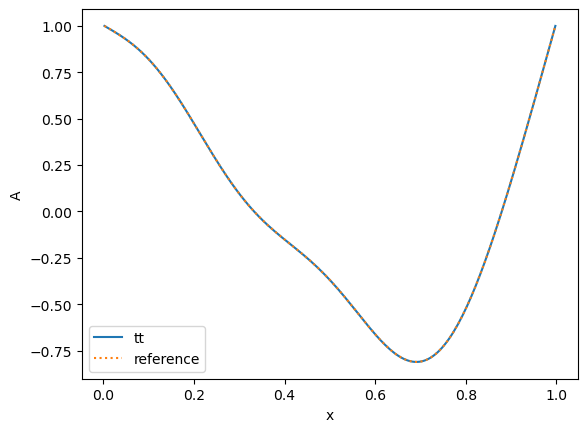

In [16]:
N_MC = 500
errs = np.zeros(N_MC)

for i in range(N_MC):
  # eval TT-approx of coeff
  y = rng.integers(0, Ny, n_a_param)
  C_eval = np.ravel(C_a[:, 0, *y])

  X = np.hstack([np.arange(Nx).reshape((-1,1)), np.zeros((Nx,1)), np.tile(y, [Nx,1])])
  C_true = cfun(X)

  errs[i] = np.linalg.norm(C_eval-C_true)

print(f'RMS l2 err = {np.sqrt(np.mean(np.square(errs))):.2e}')

fig, ax = plt.subplots()

x = (np.arange(0, Nx) + .5) / Nx
ax.plot(x, C_eval, label='tt')
ax.plot(x, C_true, ls='dotted', label="reference")
ax.set_xlabel('x')
ax.set_ylabel('A')
ax.legend()